# Interactive visualisations in Python

A short tour of interactive plotting in Python, put together for a company
webinar. Four sections, each standing on its own:

1. **What a dataset is missing** &mdash; `missingno` for a quick audit of gaps.
2. **Preparing the world data** &mdash; reshaping three Gapminder series.
3. **Population density on a map** &mdash; a GeoPandas + Plotly choropleth.
4. **Income vs. life expectancy** &mdash; an animated bubble chart, 1900&ndash;2100.

All data used here is publicly available. Both Plotly figures are saved as
standalone pages under `figures/`, since GitHub cannot render interactive output
inside a notebook.

In [ ]:
import pandas as pd
import geopandas as gpd
import missingno as msno
import plotly.express as px
import plotly.graph_objects as go

## 1. What a dataset is missing

`missingno` gives three quick reads on missing data: how much each column
actually has, where the gaps fall through the rows, and whether gaps in
different columns travel together.

> **Data:** this section uses `movies.csv` from the Kaggle dataset
> `movies-dataset-for-feature-extracion-prediction`. It is not included in this
> repo &mdash; download it to `data/movies.csv` to run the next two cells. The
> charts saved below are from the original run.

In [41]:
df = pd.read_csv('data/movies.csv')

<Axes: >

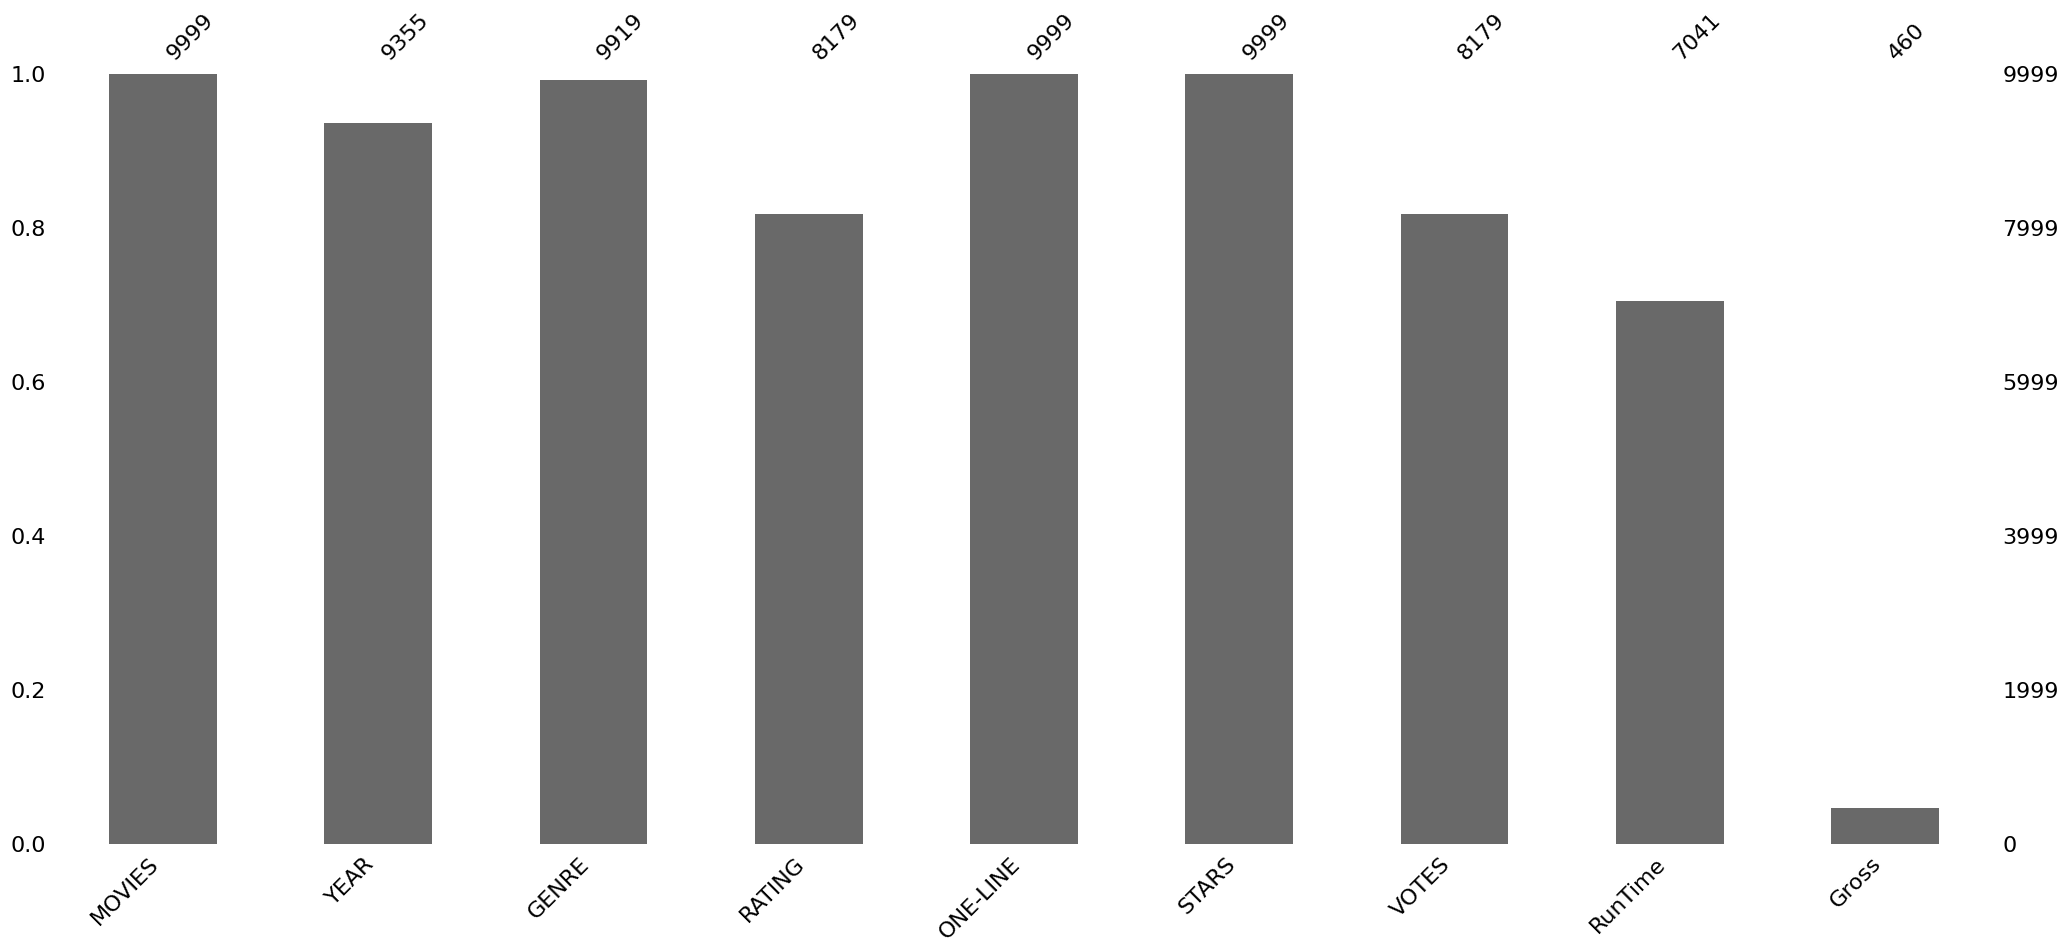

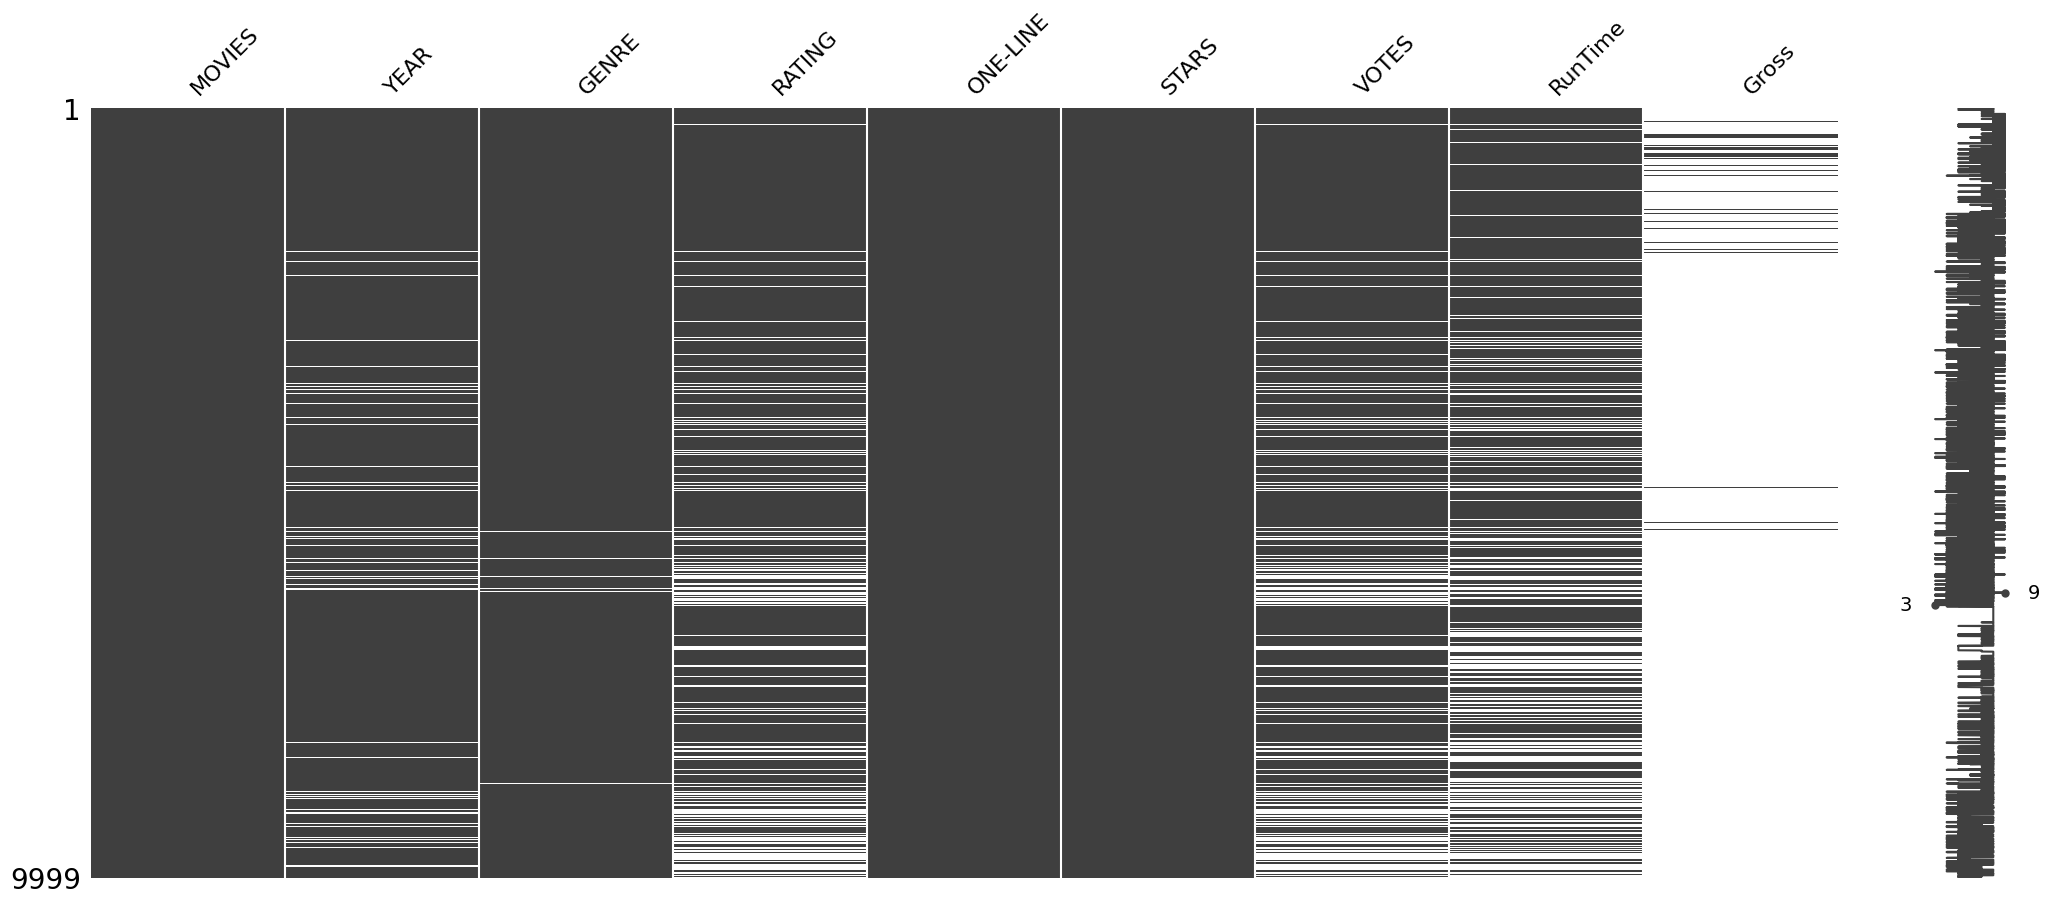

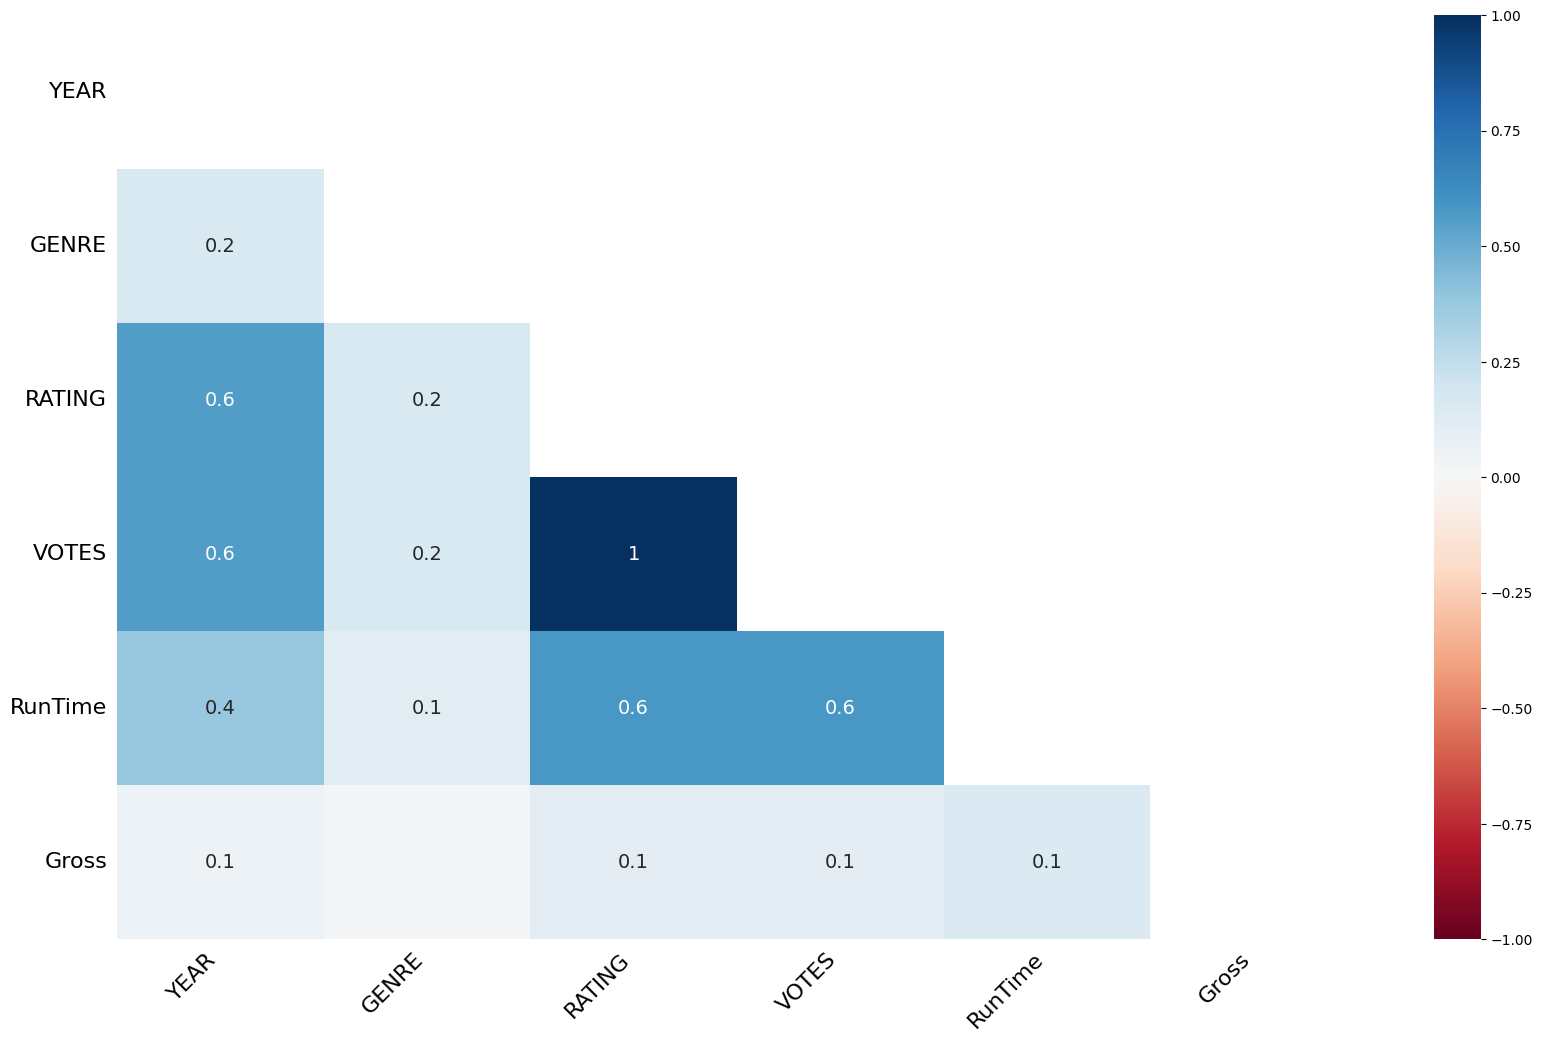

In [42]:
# VISUALISING MISSING DATA
msno.bar(df)      # how much data each column actually has
msno.matrix(df)   # where the gaps fall through the rows
msno.heatmap(df)  # whether gaps in different columns travel together

# Best to eliminate invalid data beforehand and standardise/check data formatting

## 2. Preparing the world data

Three Gapminder series &mdash; population, GDP per capita and life expectancy
&mdash; each arriving as one row per country and one column per year. The cells
below reshape them into a single long frame of one row per country per year,
convert income to 2023 pounds, and label each country with its continent.

In [43]:
df_pop = pd.read_csv('pop.csv')
df_inc = pd.read_csv('gdp_pcap.csv')
df_lex = pd.read_csv('lex.csv')

In [44]:
# functions to handle magnitude shorthands

def text_to_num(text, bad_data_val=0):
    """Turn Gapminder's shorthand ('12.4k', '3.5M') into a number."""
    magnitudes = {
        'K': 1000,
        'k': 1000,
        'M': 1000000,
        'B': 1000000000
    }
    # anything that isn't a non-empty string is missing data in the source files
    if not isinstance(text, str) or not text:
        return bad_data_val

    elif text[-1] in magnitudes:
        # separate out the K, M, or B
        num, magnitude = text[:-1], text[-1]
        return int(float(num) * magnitudes[magnitude])

    else:
        return float(text)


def num_to_text(number, precision=2):
    """Inverse of text_to_num, for hover labels."""
    if number is None:
        return "N/A"

    suffixes = ["", "K", "M", "B"]
    magnitude = 0

    while number >= 1000 and magnitude < len(suffixes) - 1:
        magnitude += 1
        number /= 1000.0

    formatted_number = f"{number:.{precision}f}"

    if formatted_number.endswith(".00"):
        formatted_number = formatted_number[:-3]  # Remove '.00' if it's an integer

    return f"{formatted_number}{suffixes[magnitude]}"

In [45]:
# merge the three series into one long frame: a row per country per year

frames = []

for year in range(1900, 2100 + 1):
    year_str = str(year)

    df_merged = (
        df_pop.loc[:, ['country', year_str]]
        .merge(df_inc.loc[:, ['country', year_str]], on='country')
        .merge(df_lex.loc[:, ['country', year_str]], on='country')
    )
    df_merged.columns = ['country', 'pop', 'inc', 'lex']

    # pop and inc use the magnitude shorthand ('12.4k'), lex is already numeric
    df_merged['pop'] = df_merged['pop'].map(text_to_num)
    df_merged['inc'] = df_merged['inc'].map(text_to_num)

    df_merged['year'] = year
    frames.append(df_merged)

df_all = pd.concat(frames, ignore_index=True)

In [46]:
# Gapminder quotes income in 2017 international dollars, so convert to GBP at
# 2023 prices. Both factors are rounded webinar-grade approximations: ~25%
# cumulative US inflation from 2017 to 2023, and ~0.82 GBP per USD (2023 average).
df_all[['pop', 'inc', 'lex']] = df_all[['pop', 'inc', 'lex']].apply(pd.to_numeric, errors='coerce')

df_all['inc'] = df_all['inc'] * 1.25  # inflation adjustment 2017 to 2023
df_all['inc'] = df_all['inc'] * 0.82  # conversion to GBP

In [47]:
# additional mapping dataset to label continents
country_to_continent = pd.read_csv('countryContinent.csv', encoding="iso-8859-1")

In [48]:
# appending extras due to naming difference
extras = pd.DataFrame([
     {"country": "UK", "continent": "Europe"},
    {"country": "USA", "continent": "Americas"},
    {"country": 'UAE', "continent": "Asia"},
    {"country": 'Bolivia', "continent": "Americas"},
    {"country": 'Brunei', "continent": "Asia"},
    {"country": "Cote d'Ivoire", "continent": "Africa"},
    {"country": 'Congo, Dem. Rep.', "continent": "Africa"},
    {"country": 'Hong Kong, China', "continent": "Asia"},
    {"country": 'Iran', "continent": "Asia"},
    {"country": 'Kyrgyz Republic', "continent": "Asia"},
    {"country": 'St. Kitts and Nevis', "continent": "Americas"},
    {"country": 'South Korea', "continent": "Asia"},
    {"country": 'Lao', "continent": "Asia"},
    {"country": 'St. Lucia', "continent": "Americas"},
    {"country": 'Moldova', "continent": "Europe"},
    {"country": 'North Macedonia', "continent": "Europe"},
    {"country": 'North Korea', "continent": "Asia"},
    {"country": 'Palestine', "continent": "Asia"},
    {"country": 'Russia', "continent": "Europe"},
    {"country": 'Slovak Republic', "continent": "Europe"},
    {"country": 'Eswatini', "continent": "Africa"},
    {"country": 'Syria', "continent": "Asia"},
    {"country": 'Taiwan', "continent": "Asia"},
    {"country": 'Tanzania', "continent": "Africa"},
    {"country": 'St. Vincent and the Grenadines', "continent": "Americas"},
    {"country": 'Venezuela', "continent": "Americas"},
    {"country": 'Vietnam', "continent": "Asia"},
    {"country": 'Congo, Rep.', "continent": "Africa"},
])

In [49]:
country_to_continent = pd.concat([country_to_continent,extras])

In [50]:
#adding continent label
df_all = df_all.merge(country_to_continent[['country','continent']], on='country', how='left')
df_all

,country,pop,inc,lex,year,continent
0,Afghanistan,4710000,867.15,33.3,1900,Asia
1,Angola,3100000,718.525,32.6,1900,Africa
2,Albania,806000,776.95,34.9,1900,Europe
3,Andorra,4520,4540.75,NaN,1900,Europe
4,UAE,48900,2849.5,35.4,1900,Asia
...,...,...,...,...,...,...
39190,Samoa,441000,16400.0,80.8,2100,Oceania
39191,Yemen,74200000,5873.25,78.0,2100,Asia
39192,South Africa,74600000,43767.5,77.7,2100,Africa
39193,Zambia,63600000,13120.0,77.1,2100,Africa


## 3. Population density on a map

A GeoPandas shapefile merged with the 2023 slice of the world data, then drawn
as an interactive Plotly choropleth. Density is population divided by projected
polygon area, so treat it as rough: Web Mercator inflates area away from the
equator, which pushes high-latitude countries like Russia and Canada lower than
they should be. The point here is the plumbing, not the demography.

> **Data:** needs a world-boundaries shapefile at `data/World_Map.shp`. Any
> shapefile with a country-name column and a geometry column will do, as long as
> the names line up with the Gapminder spellings. Not included in this repo.

In [ ]:
#create 2023 snapshot dataframe
df_2023 = df_all[df_all['year']==2023].reset_index(drop=True)
df_2023

In [52]:
gdf = gpd.read_file('data/World_Map.shp')
gdf.columns = ['country', 'geometry']

# Align a few country names with the Gapminder spelling before merging. Matched
# on the name rather than the row number (the original was gdf.loc[205] etc.),
# so this survives a shapefile whose rows come in a different order.
renames = {
    r'^United Kingdom': 'UK',
    r'^United States': 'USA',
    r'^Viet\s?Nam': 'Vietnam',
}
for pattern, name in renames.items():
    match = gdf['country'].str.contains(pattern, case=False, na=False, regex=True)
    gdf.loc[match, 'country'] = name

In [53]:
# merging 2023 dataset with shape coordinates
gdf_merged = gdf.merge(df_2023, on='country', how='outer')
gdf_merged = gdf_merged.to_crs("EPSG:3857")  # project to metres so .area is meaningful

# calculating population density
gdf_merged['area'] = gdf_merged['geometry'].area
gdf_merged['pop_den'] = gdf_merged['pop'] / gdf_merged['area']

In [54]:
# removing countries with missing coordinates
gdf_merged = gdf_merged[~gdf_merged['geometry'].isna()]

In [55]:
gdf_merged = gdf_merged.to_crs(epsg=4326)

# clamp the top of the range so the colour scale isn't dominated by city states
gdf_merged.loc[gdf_merged['pop_den'] > 0.00015, 'pop_den'] = 0.00015

# Create an interactive Plotly figure
fig = px.choropleth_map(
    gdf_merged,
    geojson=gdf_merged.geometry,
    locations=gdf_merged.index,
    color='pop_den',
    hover_name='country',
    hover_data=['pop'],
    map_style='carto-positron',
    # The whole world is square in Web Mercator, so a wide, short figure
    # clips the high latitudes. Centre north of the equator (the southern
    # half is mostly empty ocean) and give it room: this shows roughly
    # 59S to 78N, and keeping zoom at 1 stops the map repeating sideways.
    center={'lat': 28, 'lon': 0},
    zoom=1,
    title='2023 Population Density'
)
fig.update_layout(width=1200, height=760)

fig.show()

## 4. Income vs. life expectancy, animated

The Gapminder bubble chart: GDP per capita against life expectancy, bubble area
for population, colour for continent, stepping through a year per frame. The
series are smoothed with a rolling window first, otherwise the bubbles jitter
between frames.

In [56]:
# smoothing data for animation purposes

window_size = 20  # number of years to apply rolling window average
columns = ['pop', 'inc', 'lex']

# .copy() matters: without it df_smoothed is just another name for df_all and
# the smoothing overwrites the raw data in place.
df_smoothed = df_all.sort_values(['country', 'year']).copy()

df_smoothed[columns] = (
    df_smoothed.groupby('country')[columns]
    .transform(lambda s: s.rolling(window=window_size, center=True, min_periods=1)
                          .mean()
                          .interpolate(method='linear', limit_direction='both'))
)

df_smoothed = df_smoothed.sort_index()

In [58]:
# code adapted from animation example on plotly website

dataset = df_smoothed

years = [str(year) for year in range(1900,2101, 1)]
initial_year = '2023'

# make list of continents
continents = []
for continent in dataset["continent"]:
    if continent not in continents:
        continents.append(continent)
# make figure
fig_dict = {
    "data": [],
    "layout": {},
    "frames": []
}

# fill in most of layout
fig_dict["layout"]["xaxis"] = {"title": "GDP per Capita (£), in 2023 prices, adjusted for inflation", "type": "log"}
fig_dict["layout"]["yaxis"] = {"range": [20, 110],"title": "Life Expectancy"}
fig_dict["layout"]["hovermode"] = "closest"
fig_dict["layout"]["updatemenus"] = [
    {
        "buttons": [
            {
                "args": [None, {"frame": {"duration": 200, "redraw": False},
                                "fromcurrent": True, "transition": {"duration": 300,
                                                                    "easing": "quadratic-in-out"}}],
                "label": "Play",
                "method": "animate"
            },
            {
                "args": [[None], {"frame": {"duration": 0, "redraw": False},
                                  "mode": "immediate",
                                  "transition": {"duration": 0}}],
                "label": "Pause",
                "method": "animate"
            }
        ],
        "direction": "left",
        "pad": {"r": 10, "t": 87},
        "showactive": False,
        "type": "buttons",
        "x": 0.1,
        "xanchor": "right",
        "y": 0,
        "yanchor": "top"
    }
]

initial_index = years.index(initial_year) 

sliders_dict = {
    "active": initial_index,
    "yanchor": "top",
    "xanchor": "left",
    "currentvalue": {
        "font": {"size": 20},
        "prefix": "Year:",
        "visible": True,
        "xanchor": "right"
    },
    "transition": {"duration": 300, "easing": "cubic-in-out"},
    "pad": {"b": 10, "t": 50},
    "len": 0.9,
    "x": 0.1,
    "y": 0,
    "steps": []
}


#inital starting data
for continent in continents:
    dataset_by_year = dataset[dataset["year"] == int(initial_year)]
    dataset_by_year_and_cont = dataset_by_year[
        dataset_by_year["continent"] == continent]

    data_dict = {
        "x": list(dataset_by_year_and_cont["inc"]),
        "y": list(dataset_by_year_and_cont["lex"]),
        "mode": "markers",
        "text": [f"Country: {country}<br>Population: {num_to_text(pop, precision=1)}" for country, pop in
                 zip(dataset_by_year_and_cont["country"], dataset_by_year_and_cont["pop"])],
        "marker": {
            "sizemode": "area",
            "sizeref": 200000,
            "size": list(dataset_by_year_and_cont["pop"])
        },
        "name": continent
    }
    fig_dict["data"].append(data_dict)

# make frames
for year in years:
    frame = {"data": [], "name": str(year)}
    for continent in continents:
        dataset_by_year = dataset[dataset["year"] == int(year)]
        dataset_by_year_and_cont = dataset_by_year[
            dataset_by_year["continent"] == continent]

        data_dict = {
            "x": list(dataset_by_year_and_cont["inc"]),
            "y": list(dataset_by_year_and_cont["lex"]),
            "mode": "markers",
            "text": [f"Country: {country}<br>Population: {num_to_text(pop, precision=1)}" for country, pop in
                 zip(dataset_by_year_and_cont["country"], dataset_by_year_and_cont["pop"])],
            #list(dataset_by_year_and_cont["country"]),
            "marker": {
                "sizemode": "area",
                "sizeref": 200000,
                "size": list(dataset_by_year_and_cont["pop"])
            },
            "name": continent
        }
        frame["data"].append(data_dict)

    fig_dict["frames"].append(frame)
    slider_step = {"args": [
        [year],
        {"frame": {"duration": 100, "redraw": True},
         "mode": "immediate",
         "transition": {"duration": 100}}
    ],
        "label": year,
        "method": "animate"}
    sliders_dict["steps"].append(slider_step)


fig_dict["layout"]["sliders"] = [sliders_dict]

fig = go.Figure(fig_dict)

fig.update_layout(
    width=1300,  # Set the width of the figure in pixels
    height=800, # Set the height of the figure in pixels
)

fig.show()